# Day 3: Consensus topology sweep on **non-IID** SST-2 (Dirichlet α=0.5)

Reads `outputs/day3_consensus.json`. Three topologies (full, ring, star)
trained at N=8, K=100, 5000 MeZO steps. Training data is sharded via the
standard Dirichlet partition: for each class, the share to each agent is
drawn from Dir(α=0.5, ..., α=0.5). Every agent sees both classes but
with strong skew. Validation stays balanced.

Three plots:
1. val accuracy / loss vs step — task-level comparison.
   On non-IID, full graph (FedAvg) is expected to underperform smaller-gap
   topologies because aggressive averaging kills per-agent specialization.
2. log ‖θ − θ̄‖ vs consensus round — the spectral-gap demonstration
   (independent of data: contraction rate ≈ |λ₂(W)|).
3. Empirical contraction rate per topology vs theoretical |λ₂(W)|.

Compare final accuracies with Day 2 (FedAvg, IID SST-2): if non-IID
shifts the ranking or hurts full graph, that's the headline.

In [1]:
import json, math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
d = json.loads((ROOT / 'outputs' / 'day3_consensus.json').read_text())

print('config:', d['config'])
print('topologies:', list(d['topologies'].keys()))
for name, meta in d['topology_meta'].items():
    print(f"  {name}: gap={meta['spectral_gap']:.4f}, |λ₂|={meta['second_eigenvalue']:.4f}")

plt.rcParams['figure.dpi'] = 110

config: {'model': 'roberta-base', 'train_subset': 1000, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 100, 'sharding': 'dirichlet', 'dirichlet_alpha': 0.5, 'agent_class_balance': [[27, 24], [2, 14], [184, 13], [78, 64], [5, 25], [18, 3], [4, 415], [122, 2]]}
topologies: ['full', 'ring', 'star']
  full: gap=1.0000, |λ₂|=0.0000
  ring: gap=0.1953, |λ₂|=0.8047
  star: gap=0.1250, |λ₂|=0.8750


## Plot 1 — task performance (val accuracy & loss)

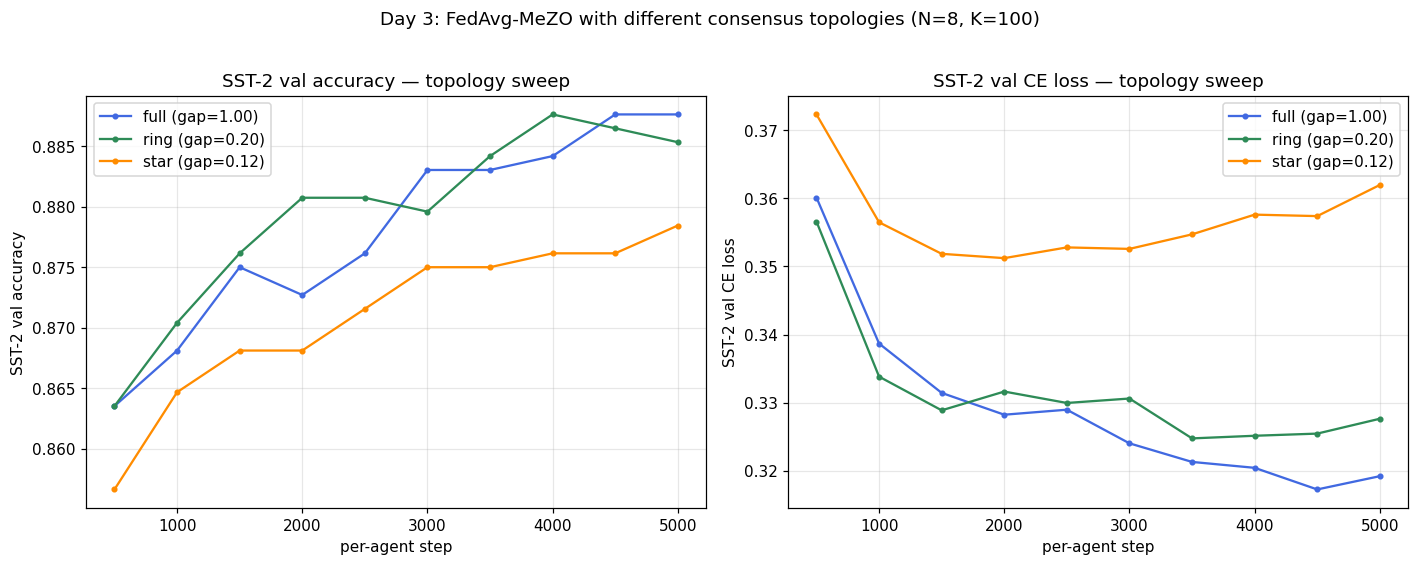

In [2]:
colors = {'full': 'royalblue', 'ring': 'seagreen', 'star': 'darkorange'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in [
    (axes[0], 'eval_acc',  'SST-2 val accuracy'),
    (axes[1], 'eval_loss', 'SST-2 val CE loss'),
]:
    for name, h in d['topologies'].items():
        ax.plot(h['eval_step'], h[key], marker='o', markersize=3,
                color=colors.get(name, 'gray'),
                label=f"{name} (gap={d['topology_meta'][name]['spectral_gap']:.2f})")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} — topology sweep")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f"Day 3: FedAvg-MeZO with different consensus topologies (N={d['config']['n_agents']}, K={d['config']['local_steps']})", y=1.02)
plt.tight_layout()

## Plot 2 — consensus residual ‖θ − θ̄‖ vs round (the headline plot)

Each consensus round multiplies the residual by ≈|λ₂(W)|. On a log scale
we should see lines whose slope matches log|λ₂|, and topologies with
larger gap (smaller |λ₂|) should drop faster.

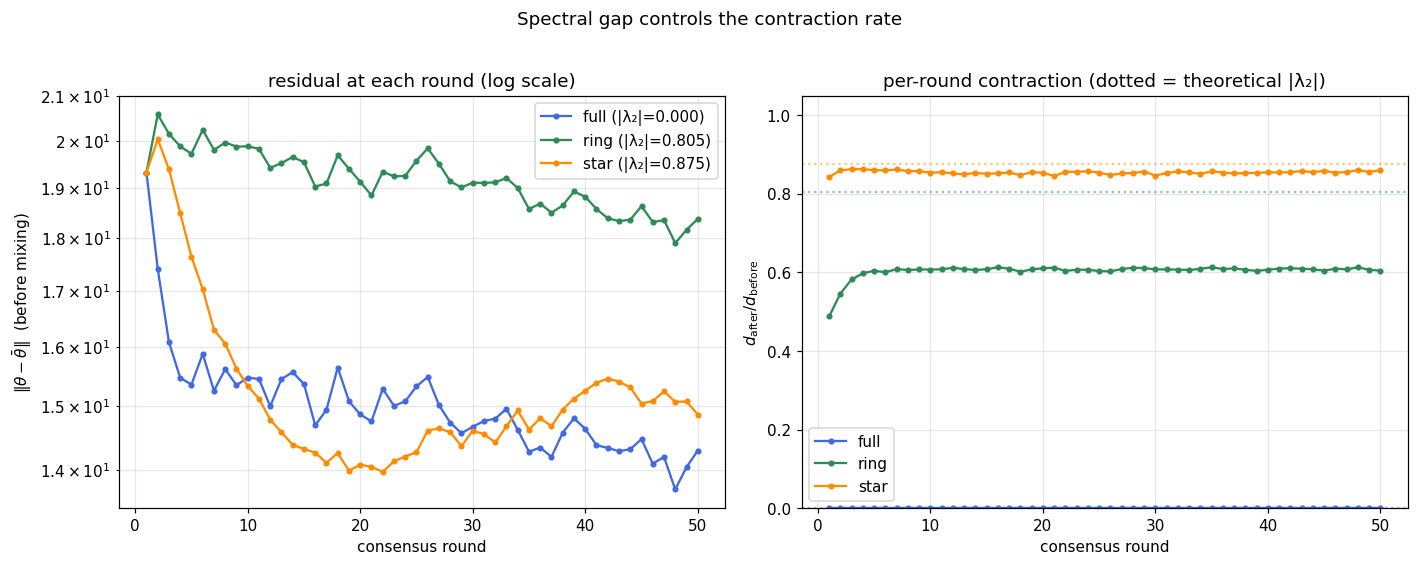

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax_before, ax_ratio = axes

for name, h in d['topologies'].items():
    rounds = np.arange(1, len(h['consensus_dist_before']) + 1)
    db = np.asarray(h['consensus_dist_before'])
    da = np.asarray(h['consensus_dist_after'])
    ratio = np.where(db > 1e-12, da / db, np.nan)

    ax_before.semilogy(rounds, db, marker='o', markersize=3,
                       color=colors.get(name, 'gray'),
                       label=f"{name} (|λ₂|={d['topology_meta'][name]['second_eigenvalue']:.3f})")
    ax_ratio.plot(rounds, ratio, marker='o', markersize=3,
                  color=colors.get(name, 'gray'),
                  label=f"{name}")
    # Theoretical horizontal line
    ax_ratio.axhline(d['topology_meta'][name]['second_eigenvalue'],
                     color=colors.get(name, 'gray'), linestyle=':', alpha=0.5)

ax_before.set_xlabel('consensus round')
ax_before.set_ylabel(r'$\|\theta - \bar\theta\|$  (before mixing)')
ax_before.set_title('residual at each round (log scale)')
ax_before.legend(); ax_before.grid(True, alpha=0.3, which='both')

ax_ratio.set_xlabel('consensus round')
ax_ratio.set_ylabel(r'$d_\mathrm{after}/d_\mathrm{before}$')
ax_ratio.set_title('per-round contraction (dotted = theoretical |λ₂|)')
ax_ratio.set_ylim(0, 1.05)
ax_ratio.legend(); ax_ratio.grid(True, alpha=0.3)

plt.suptitle('Spectral gap controls the contraction rate', y=1.02)
plt.tight_layout()

## Plot 3 — empirical vs theoretical contraction rate

In [4]:
rows = []
for name, h in d['topologies'].items():
    db = np.asarray(h['consensus_dist_before'])
    da = np.asarray(h['consensus_dist_after'])
    ratios = da[db > 1e-12] / db[db > 1e-12]
    geomean = math.exp(np.log(ratios).mean()) if len(ratios) else float('nan')
    rows.append({
        'topology':              name,
        'theoretical |λ₂|':      d['topology_meta'][name]['second_eigenvalue'],
        'empirical contraction': geomean,
        'spectral gap':          d['topology_meta'][name]['spectral_gap'],
        'final val_acc':         h['eval_acc'][-1],
    })
pd.DataFrame(rows).round(4)

C:\Users\olegk\AppData\Local\Temp\ipykernel_98892\330144137.py:6: RuntimeWarning: divide by zero encountered in log
  geomean = math.exp(np.log(ratios).mean()) if len(ratios) else float('nan')


,topology,theoretical |λ₂|,empirical contraction,spectral gap,final val_acc
0,full,0.0000,0.0000,1.0000,0.8876
1,ring,0.8047,0.6032,0.1953,0.8853
2,star,0.8750,0.8548,0.1250,0.8784
